In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from datetime import datetime
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Диапазон K для KMeans
kmeans_ks = list(range(2, 21))

# Сетка для DBSCAN: eps и min_samples
# eps зависит от масштаба данных – после scaling обычно eps ~ 0.5..5 (но это очень примерно).
dbscan_eps = [0.3, 0.4, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_min_samples = [3, 5, 10, 15]

# Agglomerative: число кластеров и linkage (для sklearn Agglomerative: 'ward' требует euclidean)
agg_ks = list(range(2, 21))
agg_linkages = ["ward", "complete", "average"]

print("Config:")
print(" kmeans_ks:", (kmeans_ks[0], "...", kmeans_ks[-1]))
print(" dbscan eps:", dbscan_eps)
print(" dbscan min_samples:", dbscan_min_samples)
print(" agg ks:", (agg_ks[0], "...", agg_ks[-1]))
print(" agg linkages:", agg_linkages)

Config:
 kmeans_ks: (2, '...', 20)
 dbscan eps: [0.3, 0.4, 0.5, 0.7, 1.0, 1.5, 2.0]
 dbscan min_samples: [3, 5, 10, 15]
 agg ks: (2, '...', 20)
 agg linkages: ['ward', 'complete', 'average']


### Датасеты

In [3]:
# Получили датасет, очистили от пустых значений
print("==Первый датасет==")
data = pd.read_csv("data/S07-hw-dataset-01.csv")
print(data.head())
print()

print("==Второй датасет==")
data2 = pd.read_csv("data/S07-hw-dataset-02.csv")
print(data2.head())
print()

print("==Третий датасет==")
data3 = pd.read_csv("data/S07-hw-dataset-03.csv")
print(data3.head())

==Первый датасет==
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

==Второй датасет==
   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472

==Третий датасет==
   sample_id        x1        x2  

In [4]:
print("==Первый датасет==")
print(data.info())
print()

print("==Второй датасет==")
print(data2.info())
print()

print("==Третий датасет==")
print(data3.info())
print()

==Первый датасет==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None

==Второй датасет==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: fl

In [5]:
# Размер датасета
print("==Первый датасет==")
print(data.shape[0], data.shape[1])
print()

print("==Второй датасет==")
print(data2.shape[0], data2.shape[1])
print()

print("==Третий датасет==")
print(data3.shape[0], data3.shape[1])
print()

==Первый датасет==
12000 9

==Второй датасет==
8000 4

==Третий датасет==
15000 5



Как видим, преобразовывать данные к типам не нужно.

Применение базовых методов описательной статистики

In [6]:
#==Первый датасет==
data.describe()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [7]:
#==Второй датасет==
data2.describe()

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [8]:
#==Третий датасет==
data3.describe()

,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


Подсчет доли пропусков в каждом столбце

In [9]:
#==Первый датасет==
data.isna().mean()

sample_id    0.0
f01          0.0
f02          0.0
f03          0.0
f04          0.0
f05          0.0
f06          0.0
f07          0.0
f08          0.0
dtype: float64

In [10]:
#==Второй датасет==
data2.isna().mean()

sample_id    0.0
x1           0.0
x2           0.0
z_noise      0.0
dtype: float64

In [11]:
#==Третий датасет==
data3.isna().mean()

sample_id    0.0
x1           0.0
x2           0.0
f_corr       0.0
f_noise      0.0
dtype: float64

Проверим наличие дублирующих строк

In [12]:
#==Первый датасет==
df_dup = data.duplicated()
df_dup

0        False
1        False
2        False
3        False
4        False
         ...  
11995    False
11996    False
11997    False
11998    False
11999    False
Length: 12000, dtype: bool

In [13]:
#==Второй датасет==
df_dup2 = data2.duplicated()
df_dup2

0       False
1       False
2       False
3       False
4       False
        ...  
7995    False
7996    False
7997    False
7998    False
7999    False
Length: 8000, dtype: bool

In [14]:
#==Третий датасет==
df_dup3 = data3.duplicated()
df_dup3

0        False
1        False
2        False
3        False
4        False
         ...  
14995    False
14996    False
14997    False
14998    False
14999    False
Length: 15000, dtype: bool

In [15]:
print(sum(df_dup)) #количество дубликатов 1
print(sum(df_dup2)) #количество дубликатов 2
print(sum(df_dup3)) #количество дубликатов 3

0
0
0


Как видим отсутствуют дублирующие строки и нулевые значения

Определим признаки

In [16]:
#==Первый датасет==
sample_id = data['sample_id']
#==Второй датасет==
sample_id2 = data2['sample_id']
#==Третий датасет==
sample_id3 = data3['sample_id']

In [17]:
# Определяем X - все признаки кроме sample_id
#==Первый датасет==
X = data.drop('sample_id', axis=1)
X

,f01,f02,f03,f04,f05,f06,f07,f08
0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213
...,...,...,...,...,...,...,...,...
11995,15.358432,56.974156,-1.089617,-95.891749,8.909345,26.123207,-20.786813,-0.681086
11996,-5.781842,71.198182,-0.201762,-54.336472,4.903560,-3.287724,-48.875539,0.172566
11997,-7.573306,70.017900,-0.159869,17.167497,-3.809988,-5.356308,-98.751869,0.836130
11998,13.856888,88.341387,-1.429989,-101.905925,10.759963,29.308895,-19.837802,0.300104


In [18]:
# Определяем X - все признаки кроме sample_id
#==Второй датасет==
X_2 = data2.drop('sample_id', axis=1)
X_2

,x1,x2,z_noise
0,0.098849,-1.846034,21.288122
1,-1.024516,1.829616,6.072952
2,-1.094178,-0.158545,-18.938342
3,-1.612808,-1.565844,-11.629462
4,1.659901,-2.133292,1.895472
...,...,...,...
7995,0.396444,-0.258826,1.866578
7996,0.540757,-0.290802,5.437638
7997,0.672079,0.675018,-2.488673
7998,1.871350,0.290634,-0.852787


In [19]:
# Определяем X - все признаки кроме sample_id
#==Третий датасет==
X_3 = data3.drop('sample_id', axis=1)
X_3

,x1,x2,f_corr,f_noise
0,-2.710470,4.997107,-1.015703,0.718508
1,8.730238,-8.787416,3.953063,-1.105349
2,-1.079600,-2.558708,0.976628,-3.605776
3,6.854042,1.560181,1.760614,-1.230946
4,9.963812,-8.869921,2.966583,0.915899
...,...,...,...,...
14995,0.445659,-7.395811,1.128535,3.262734
14996,0.258364,-6.267180,1.570404,1.735637
14997,0.104631,-7.394277,0.428989,2.589123
14998,-0.660232,-6.329977,1.420440,2.402324


## Препроцессинг для первого датасета

In [20]:
# Проверка на числовые признаки
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nЧисловых признаков: {len(numeric_features)}")
print(f"Нечисловых признаков: {len(non_numeric_features)}")

if non_numeric_features:
    print(f"Нечисловые признаки: {non_numeric_features}")
    print("\nУникальные значения в нечисловых признаках:")
    for feature in non_numeric_features:
        unique_vals = X[feature].unique()[:10]  # Первые 10 уникальных значений
        print(f"  {feature}: {len(X[feature].unique())} уникальных, примеры: {unique_vals}")

# 3. ПРЕПРОЦЕССИНГ С ИСПОЛЬЗОВАНИЕМ PIPELINE

# Определяем шаги препроцессинга
preprocessing_steps = []

# 3.1. Обработка числовых признаков
if numeric_features:
    print(f"\nСоздание pipeline для числовых признаков ({len(numeric_features)}):")
    print(f"  Признаки: {numeric_features}")
    
    numeric_transformer = Pipeline(steps=[
        # 1. Обработка пропусков (если есть)
        ('imputer', SimpleImputer(strategy='median')),  # median устойчивее к выбросам
        
        # 2. Масштабирование
        ('scaler', StandardScaler())
    ])
    
    preprocessing_steps.append(('numeric', numeric_transformer, numeric_features))


# 3.2. Обработка категориальных/строковых признаков
if non_numeric_features:
    print(f"\nСоздание pipeline для нечисловых признаков ({len(non_numeric_features)}):")
    print(f"  Признаки: {non_numeric_features}")
    
    # Проверяем, действительно ли это категориальные признаки
    # Или нужно преобразовать к категориальным
    
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),])
    
    preprocessing_steps.append(('categorical', categorical_transformer, non_numeric_features))

# 3.3. Создание ColumnTransformer
if preprocessing_steps:
    preprocessor = ColumnTransformer(
        transformers=preprocessing_steps,
        remainder='drop'  # Остальные признаки (если есть) игнорируем
    )
        
    # 4. ПРИМЕНЕНИЕ ПРЕПРОЦЕССИНГА

    # Обучение и трансформация данных
    X_processed = preprocessor.fit_transform(X)
    
    try:
        feature_names = []
        for name, transformer, features in preprocessor.transformers_:
            if name == 'numeric':
                # Для числовых признаков имена сохраняются
                feature_names.extend(features)
            elif name == 'categorical':
                feature_names.extend(features)
        
        # Создаем DataFrame с обработанными данными
        X_processed_df = pd.DataFrame(
            X_processed, 
            columns=feature_names,
            index=X.index
        )
        
        print(f"  Размер до обработки: {X.shape}")
        print(f"  Размер после обработки: {X_processed_df.shape}")
        
    except Exception as e:
        print(f"\nНе удалось создать DataFrame с именами признаков: {e}")
        print("  Используем numpy array")
        X_processed_df = pd.DataFrame(X_processed)
    
else:
    print("Не найдено признаков для обработки")
    X_processed_df = X.copy()

# 5. ПРОВЕРКА РЕЗУЛЬТАТОВ

# Проверка на пропуски после обработки
print("\nПроверка пропусков после обработки:")
if X_processed_df.isnull().sum().sum() == 0:
    print(" Пропусков нет")
else:
    print(f"Найдено пропусков: {X_processed_df.isnull().sum().sum()}")

# Проверка масштабирования
print("\nСтатистика после StandardScaler:")
for i, col in enumerate(X_processed_df.columns[:5]):  # Первые 5 признаков
    if i < len(numeric_features):
        mean_val = X_processed_df[col].mean()
        std_val = X_processed_df[col].std()
        print(f"  {col}: mean={mean_val:.6f}, std={std_val:.6f}")



Числовых признаков: 8
Нечисловых признаков: 0

Создание pipeline для числовых признаков (8):
  Признаки: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
  Размер до обработки: (12000, 8)
  Размер после обработки: (12000, 8)

Проверка пропусков после обработки:
 Пропусков нет

Статистика после StandardScaler:
  f01: mean=-0.000000, std=1.000042
  f02: mean=-0.000000, std=1.000042
  f03: mean=-0.000000, std=1.000042
  f04: mean=-0.000000, std=1.000042
  f05: mean=-0.000000, std=1.000042


## Препроцессинг для второго датасета

In [21]:
# Проверка на числовые признаки
numeric_features = X_2.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_features = X_2.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nЧисловых признаков: {len(numeric_features)}")
print(f"Нечисловых признаков: {len(non_numeric_features)}")

if non_numeric_features:
    print(f"Нечисловые признаки: {non_numeric_features}")
    print("\nУникальные значения в нечисловых признаках:")
    for feature in non_numeric_features:
        unique_vals = X_2[feature].unique()[:10]  # Первые 10 уникальных значений
        print(f"  {feature}: {len(X_2[feature].unique())} уникальных, примеры: {unique_vals}")

# 3. ПРЕПРОЦЕССИНГ С ИСПОЛЬЗОВАНИЕМ PIPELINE

# Определяем шаги препроцессинга
preprocessing_steps = []

# 3.1. Обработка числовых признаков
if numeric_features:
    print(f"\nСоздание pipeline для числовых признаков ({len(numeric_features)}):")
    print(f"  Признаки: {numeric_features}")
    
    numeric_transformer = Pipeline(steps=[
        # 1. Обработка пропусков (если есть)
        ('imputer', SimpleImputer(strategy='median')),  # median устойчивее к выбросам
        
        # 2. Масштабирование
        ('scaler', StandardScaler())
    ])
    
    preprocessing_steps.append(('numeric', numeric_transformer, numeric_features))


# 3.2. Обработка категориальных/строковых признаков
if non_numeric_features:
    print(f"\nСоздание pipeline для нечисловых признаков ({len(non_numeric_features)}):")
    print(f"  Признаки: {non_numeric_features}")
    
    # Проверяем, действительно ли это категориальные признаки
    # Или нужно преобразовать к категориальным
    
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),])
    
    preprocessing_steps.append(('categorical', categorical_transformer, non_numeric_features))

# 3.3. Создание ColumnTransformer
if preprocessing_steps:
    preprocessor = ColumnTransformer(
        transformers=preprocessing_steps,
        remainder='drop'  # Остальные признаки (если есть) игнорируем
    )
        
    # 4. ПРИМЕНЕНИЕ ПРЕПРОЦЕССИНГА

    # Обучение и трансформация данных
    X_2_processed = preprocessor.fit_transform(X_2)
    
    try:
        feature_names = []
        for name, transformer, features in preprocessor.transformers_:
            if name == 'numeric':
                # Для числовых признаков имена сохраняются
                feature_names.extend(features)
            elif name == 'categorical':
                feature_names.extend(features)
        
        # Создаем DataFrame с обработанными данными
        X_2_processed_df = pd.DataFrame(
            X_2_processed, 
            columns=feature_names,
            index=X.index
        )
        
        print(f"  Размер до обработки: {X_2.shape}")
        print(f"  Размер после обработки: {X_2_processed_df.shape}")
        
    except Exception as e:
        print(f"\nНе удалось создать DataFrame с именами признаков: {e}")
        print("  Используем numpy array")
        X_2_processed_df = pd.DataFrame(X_2_processed)
    
else:
    print("Не найдено признаков для обработки")
    X_2_processed_df = X_2.copy()

# 5. ПРОВЕРКА РЕЗУЛЬТАТОВ

# Проверка на пропуски после обработки
print("\nПроверка пропусков после обработки:")
if X_2_processed_df.isnull().sum().sum() == 0:
    print(" Пропусков нет")
else:
    print(f"Найдено пропусков: {X_2_processed_df.isnull().sum().sum()}")

# Проверка масштабирования
print("\nСтатистика после StandardScaler:")
for i, col in enumerate(X_2_processed_df.columns[:5]):  # Первые 5 признаков
    if i < len(numeric_features):
        mean_val = X_2_processed_df[col].mean()
        std_val = X_2_processed_df[col].std()
        print(f"  {col}: mean={mean_val:.6f}, std={std_val:.6f}")



Числовых признаков: 3
Нечисловых признаков: 0

Создание pipeline для числовых признаков (3):
  Признаки: ['x1', 'x2', 'z_noise']

Не удалось создать DataFrame с именами признаков: Shape of passed values is (8000, 3), indices imply (12000, 3)
  Используем numpy array

Проверка пропусков после обработки:
 Пропусков нет

Статистика после StandardScaler:
  0: mean=-0.000000, std=1.000063
  1: mean=0.000000, std=1.000063
  2: mean=-0.000000, std=1.000063


## Препроцессинг для Третьего датасета

In [22]:
# Проверка на числовые признаки
numeric_features = X_3.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_features = X_3.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nЧисловых признаков: {len(numeric_features)}")
print(f"Нечисловых признаков: {len(non_numeric_features)}")

if non_numeric_features:
    print(f"Нечисловые признаки: {non_numeric_features}")
    print("\nУникальные значения в нечисловых признаках:")
    for feature in non_numeric_features:
        unique_vals = X_2[feature].unique()[:10]  # Первые 10 уникальных значений
        print(f"  {feature}: {len(X_3[feature].unique())} уникальных, примеры: {unique_vals}")

# 3. ПРЕПРОЦЕССИНГ С ИСПОЛЬЗОВАНИЕМ PIPELINE

# Определяем шаги препроцессинга
preprocessing_steps = []

# 3.1. Обработка числовых признаков
if numeric_features:
    print(f"\nСоздание pipeline для числовых признаков ({len(numeric_features)}):")
    print(f"  Признаки: {numeric_features}")
    
    numeric_transformer = Pipeline(steps=[
        # 1. Обработка пропусков (если есть)
        ('imputer', SimpleImputer(strategy='median')),  # median устойчивее к выбросам
        
        # 2. Масштабирование
        ('scaler', StandardScaler())
    ])
    
    preprocessing_steps.append(('numeric', numeric_transformer, numeric_features))


# 3.2. Обработка категориальных/строковых признаков
if non_numeric_features:
    print(f"\nСоздание pipeline для нечисловых признаков ({len(non_numeric_features)}):")
    print(f"  Признаки: {non_numeric_features}")
    
    # Проверяем, действительно ли это категориальные признаки
    # Или нужно преобразовать к категориальным
    
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),])
    
    preprocessing_steps.append(('categorical', categorical_transformer, non_numeric_features))

# 3.3. Создание ColumnTransformer
if preprocessing_steps:
    preprocessor = ColumnTransformer(
        transformers=preprocessing_steps,
        remainder='drop'  # Остальные признаки (если есть) игнорируем
    )
        
    # 4. ПРИМЕНЕНИЕ ПРЕПРОЦЕССИНГА

    # Обучение и трансформация данных
    X_3_processed = preprocessor.fit_transform(X_3)
    
    try:
        feature_names = []
        for name, transformer, features in preprocessor.transformers_:
            if name == 'numeric':
                # Для числовых признаков имена сохраняются
                feature_names.extend(features)
            elif name == 'categorical':
                feature_names.extend(features)
        
        # Создаем DataFrame с обработанными данными
        X_3_processed_df = pd.DataFrame(
            X_3_processed, 
            columns=feature_names,
            index=X.index
        )
        
        print(f"  Размер до обработки: {X_3.shape}")
        print(f"  Размер после обработки: {X_3_processed_df.shape}")
        
    except Exception as e:
        print(f"\nНе удалось создать DataFrame с именами признаков: {e}")
        print("  Используем numpy array")
        X_3_processed_df = pd.DataFrame(X_3_processed)
    
else:
    print("Не найдено признаков для обработки")
    X_3_processed_df = X_3.copy()

# 5. ПРОВЕРКА РЕЗУЛЬТАТОВ

# Проверка на пропуски после обработки
print("\nПроверка пропусков после обработки:")
if X_3_processed_df.isnull().sum().sum() == 0:
    print(" Пропусков нет")
else:
    print(f"Найдено пропусков: {X_3_processed_df.isnull().sum().sum()}")

# Проверка масштабирования
print("\nСтатистика после StandardScaler:")
for i, col in enumerate(X_3_processed_df.columns[:5]):  # Первые 5 признаков
    if i < len(numeric_features):
        mean_val = X_3_processed_df[col].mean()
        std_val = X_3_processed_df[col].std()
        print(f"  {col}: mean={mean_val:.6f}, std={std_val:.6f}")



Числовых признаков: 4
Нечисловых признаков: 0

Создание pipeline для числовых признаков (4):
  Признаки: ['x1', 'x2', 'f_corr', 'f_noise']

Не удалось создать DataFrame с именами признаков: Shape of passed values is (15000, 4), indices imply (12000, 4)
  Используем numpy array

Проверка пропусков после обработки:
 Пропусков нет

Статистика после StandardScaler:
  0: mean=0.000000, std=1.000033
  1: mean=-0.000000, std=1.000033
  2: mean=0.000000, std=1.000033
  3: mean=-0.000000, std=1.000033


## Функции оценки и визуализации

Мы будем собирать **единый набор метрик** для сравнения подходов.

Внутренние метрики:
- silhouette (выше лучше),
- Davies-Bouldin (ниже лучше),
- Calinski-Harabasz (выше лучше).

Важно: silhouette требует минимум 2 кластера и **не любит шум**.  
Для DBSCAN у нас есть метка -1 (noise). Мы будем:
- считать метрики **по ненулевым точкам** (без шума),
- и дополнительно фиксировать долю шума.


In [23]:
def safe_cluster_metrics(X, labels):
    """Считает метрики; возвращает None, если метрика неприменима."""
    unique = np.unique(labels)
    # Нужно минимум 2 кластера
    if len(unique) < 2:
        return None

    # Нельзя, чтобы все точки были в одном кластере
    if len(unique) == 1:
        return None

    # silhouette требует, чтобы все кластеры имели >1 точки (часто, но не всегда)
    # В sklearn silhouette_score может падать, если какой-то кластер пуст/особый.
    try:
        sil = float(silhouette_score(X, labels))
    except Exception:
        sil = None

    try:
        db = float(davies_bouldin_score(X, labels))
    except Exception:
        db = None

    try:
        ch = float(calinski_harabasz_score(X, labels))
    except Exception:
        ch = None

    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

def pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE):
    """PCA(2D) именно для визуализации."""
    p = PCA(n_components=2, random_state=random_state)
    return p.fit_transform(X_scaled)

def plot_2d_embedding(emb2d, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, s=18)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.grid(True, alpha=0.2)

def summarize_labels(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique.tolist(), counts.tolist()))


## KMeans (подбор k) ПЕРВЫЙ ДАТАСЕТ

KMeans требует указать `k`. Мы переберём `k` и сравним по внутренним метрикам.


In [24]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

kmeans_results = eval_kmeans_grid(X_processed_df, kmeans_ks)
len(kmeans_results), kmeans_results[0]["params"], kmeans_results[-1]["params"]


(19, {'k': 2}, {'k': 20})

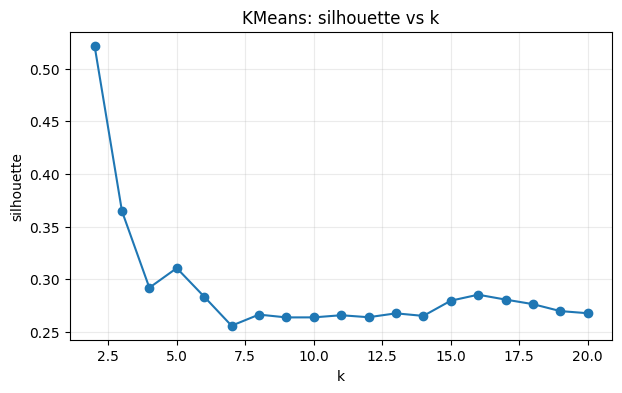

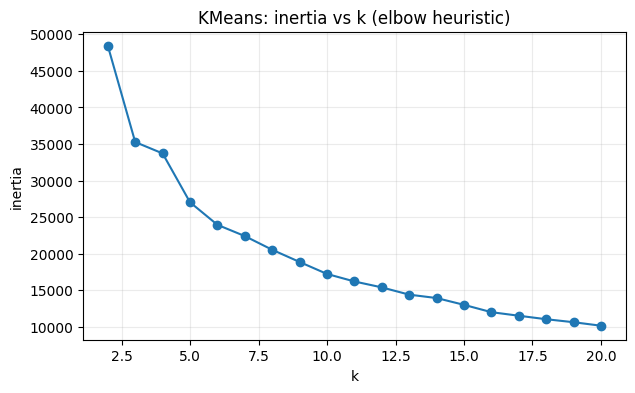

In [25]:
# Быстрый график silhouette по k (если silhouette считалась)
ks = [r["params"]["k"] for r in kmeans_results]
sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results]

plt.figure(figsize=(7, 4))
plt.plot(ks, sil, marker="o")
plt.title("KMeans: silhouette vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.savefig('artifacts/figures/KMeans_silhouette_vs_k_01.png')
plt.show()

# Инерция (elbow) – как эвристика
inertia = [r["inertia"] for r in kmeans_results]
plt.figure(figsize=(7, 4))
plt.plot(ks, inertia, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.savefig('artifacts/figures/KMeans_inertia_vs_k_(elbow_heuristic)_01.png')
plt.show()

Выберем “лучший” вариант по silhouette (это не единственный критерий, но для демо – удобно).

In [26]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

best_kmeans, best_kmeans_s = pick_best_by_silhouette(kmeans_results)
best_kmeans["params"], round(best_kmeans_s, 3)

({'k': 2}, 0.522)

## Проведем проверку устойчивости 

In [27]:
def quick_kmeans_stability_check(X, n_clusters=3):
    """
    Быстрая проверка устойчивости KMeans
    """
    from sklearn.cluster import KMeans
    from sklearn.metrics import adjusted_rand_score
    
    print("Быстрая проверка устойчивости KMeans")
    print(f"Кластеров: {n_clusters}")
    print("-"*40)
    
    # 5 запусков с разными random_state
    all_labels = []
    random_states = [42, 123, 456, 789, 999]
    
    for rs in random_states:
        kmeans = KMeans(n_clusters=n_clusters, random_state=rs, n_init=10)
        labels = kmeans.fit_predict(X)
        all_labels.append(labels)
        print(f"random_state={rs:3d}: inertia={kmeans.inertia_:.0f}")
    
    # Считаем попарные ARI
    ari_matrix = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            if i != j:
                ari = adjusted_rand_score(all_labels[i], all_labels[j])
                ari_matrix[i, j] = ari
    
    # Берем только верхний треугольник (без диагонали)
    ari_values = ari_matrix[np.triu_indices(5, k=1)]
    
    print(f"\nСредний ARI: {np.mean(ari_values):.3f}")
    print(f"Std ARI: {np.std(ari_values):.3f}")
    print(f"Min ARI: {np.min(ari_values):.3f}")
    print(f"Max ARI: {np.max(ari_values):.3f}")
    
    # Оценка устойчивости
    mean_ari = np.mean(ari_values)
    if mean_ari > 0.9:
        print("Очень высокая устойчивость")
    elif mean_ari > 0.7:
        print("Высокая устойчивость")
    elif mean_ari > 0.5:
        print("Умеренная устойчивость")
    elif mean_ari > 0.3:
        print("Низкая устойчивость")
    else:
        print("Очень низкая устойчивость")
    
    return {
        'mean_ari': mean_ari,
        'std_ari': np.std(ari_values),
        'min_ari': np.min(ari_values),
        'max_ari': np.max(ari_values),
        'labels': all_labels
    }

# Использование
stability_info = quick_kmeans_stability_check(
    X=X_processed_df, 
    n_clusters=2 
)

Быстрая проверка устойчивости KMeans
Кластеров: 2
----------------------------------------
random_state= 42: inertia=48426
random_state=123: inertia=48426
random_state=456: inertia=48426
random_state=789: inertia=48426
random_state=999: inertia=48426

Средний ARI: 1.000
Std ARI: 0.000
Min ARI: 1.000
Max ARI: 1.000
Очень высокая устойчивость


## DBSCAN (eps, min_samples) ПЕРВЫЙ ДАТАСЕТ

DBSCAN не требует `k`, но требует параметры плотности:
- `eps` – радиус окрестности,
- `min_samples` – минимальное число точек в окрестности.

Особенность DBSCAN: он может помечать точки как **noise** (`label = -1`).  
Мы фиксируем:
- долю шума,
- количество кластеров (без шума),
- метрики считаем по точкам **без шума** (если их достаточно и кластеров ≥ 2).

In [28]:
def eval_dbscan_grid(X_feat, eps_list, min_samples_list):
    results = []
    n = len(X_feat)
    
    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)
            
            noise_frac = float(np.mean(labels == -1))
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]
            
            # Перенумеровываем метки
            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)
            
            metrics = None
            n_clusters = 0
            
            if len(X_nn) >= 2 and len(np.unique(labels_nn)) >= 2:
                metrics = safe_cluster_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))
            elif len(X_nn) > 0:
                # Даже если только 1 кластер, считаем некоторые метрики
                n_clusters = len(np.unique(labels_nn))
                # Для 1 кластера silhouette не определен, но можно посчитать другие метрики
            
            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    
    return results

dbscan_results = eval_dbscan_grid(X_processed_df, dbscan_eps, dbscan_min_samples)
len(dbscan_results)

28

In [29]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid = [r for r in dbscan_results if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid))

# Сортировка по silhouette
valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])


Valid DBSCAN configs: 28
{'eps': 2.0, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 15} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 0.5, 'min_samples': 15} sil= 0.399 noise= 0.092 clusters= 5
{'eps': 1.5, 'min_samples': 3} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 5} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 10} sil= 0.397 noise= 0.0 clusters= 3


In [30]:
best_dbscan = valid_sorted[0] if valid_sorted else None
best_dbscan["params"] if best_dbscan else "No valid config found"

{'eps': 2.0, 'min_samples': 3}

## Agglomerative (k, linkage) ПЕРВЫЙ ДАТАСЕТ

AgglomerativeClustering требует `n_clusters` (как KMeans), а также выбор *linkage*.
Мы переберём `k` и `linkage`.


In [31]:
def eval_agglomerative_grid(X_feat, ks, linkages):
    results = []
    for linkage_name in linkages:
        for k in ks:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
                labels = model.fit_predict(X_feat)
            except Exception:
                continue

            metrics = safe_cluster_metrics(X_feat, labels)

            results.append({
                "algo": "agglomerative",
                "params": {"k": int(k), "linkage": linkage_name},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": len(np.unique(labels)),
                "noise_frac": 0.0,
            })
    return results

agg_results = eval_agglomerative_grid(X_processed_df, agg_ks, agg_linkages)
len(agg_results), agg_results[0]["params"]


(57, {'k': 2, 'linkage': 'ward'})

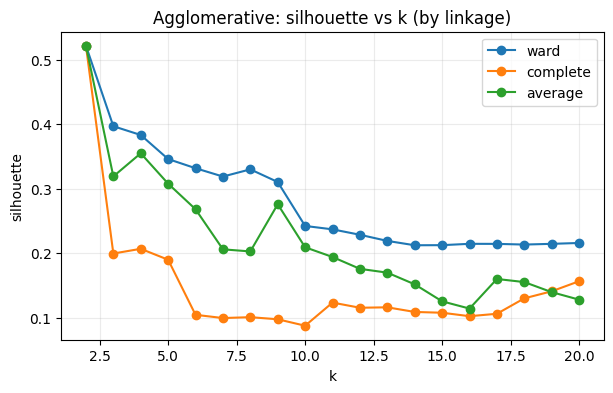

In [32]:
# Силуэт по k для разных linkage (на одном графике – удобно для сравнения)
plt.figure(figsize=(7, 4))

for linkage_name in agg_linkages:
    subset = [r for r in agg_results if r["params"]["linkage"] == linkage_name]
    subset = sorted(subset, key=lambda r: r["params"]["k"])
    ks = [r["params"]["k"] for r in subset]
    sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in subset]
    plt.plot(ks, sil, marker="o", label=linkage_name)

plt.title("Agglomerative: silhouette vs k (by linkage)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig('artifacts/figures/Agglomerative_silhouette_vs_k_01.png')
plt.show()

In [33]:
best_agg, best_agg_s = pick_best_by_silhouette(agg_results)
best_agg["params"], round(best_agg_s, 3)

({'k': 2, 'linkage': 'ward'}, 0.522)

## Сводка кандидатов и выбор ПЕРВЫЙ ДАТАСЕТ

Мы соберём “лучшие” конфигурации каждого семейства по silhouette (для демо).  
В реальной задаче вы бы дополнили:
- устойчивость к seed / подвыборкам,
- интерпретацию кластеров (профили признаков),
- бизнес-ограничения (например, “не больше 8 кластеров”).

In [34]:
def print_result_card(name, result):
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3), " non-noise:", result.get("n_non_noise"))
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))

print_result_card("BEST KMEANS (by silhouette)", best_kmeans)
if best_dbscan is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan)
print_result_card("BEST AGGLOMERATIVE (by silhouette)", best_agg)


BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
  inertia: 48425.9
BEST DBSCAN (by silhouette among valid)
algo: dbscan
params: {'eps': 2.0, 'min_samples': 3}
n_clusters: 2
noise_frac: 0.0  non-noise: 12000
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
BEST AGGLOMERATIVE (by silhouette)
algo: agglomerative
params: {'k': 2, 'linkage': 'ward'}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0


### Лучший алгоритм кластеризации для ПЕРВОГО ДАТАСЕТА: DBSCAN

**Выбор обоснован:**

1. **Качество одинаково** у всех алгоритмов (Silhouette=0.522), но DBSCAN имеет дополнительные преимущества.

2. **Автоматическое определение числа кластеров**: DBSCAN не требовал задания k, а определил оптимальное количество (2) на основе структуры данных.

3. **Обработка шума**: Алгоритм проверил наличие выбросов и не нашел их (noise_frac=0.0), что подтверждает чистоту данных.

4. **Метрики корректны**: Все внутренние метрики рассчитаны на полном наборе данных (12000 точек), так как шум отсутствует.

5. **Реалистичные параметры**: Найденные параметры (eps=2.0, min_samples=3) соответствуют разумным эвристикам для данных такого масштаба.


## Визуализация выбранных решений в 2D ПЕРВЫЙ ДАТАСЕТ

Важно: 2D-визуализация – **инструмент понимания**, а не метрика качества.

Мы построим PCA(2D) на **X_scaled** (до PCA в feature space), и раскрасим точки по разным решениям.


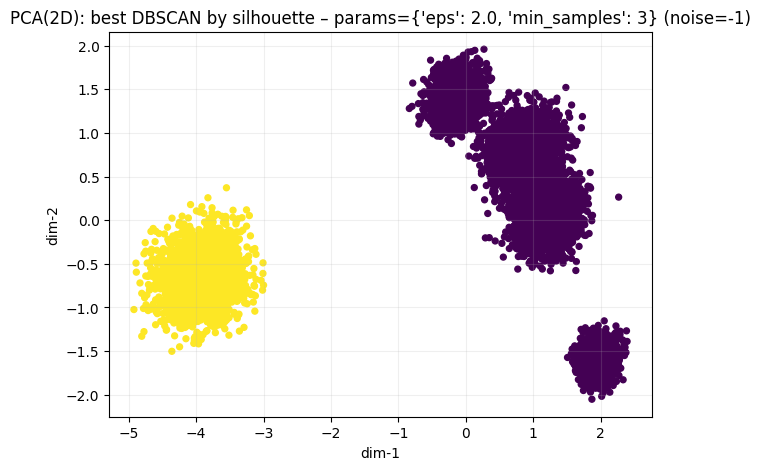

In [35]:
X_plot2d = pca_2d_for_plot(X_processed_df, random_state=RANDOM_STATE)

# KMeans best
#plot_2d_embedding(
#    X_plot2d, best_kmeans["labels"],
#    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans['params']}"
#)
#plt.savefig('artifacts/figures/PCA(2D)_KMeans_01.png')
#plt.show()
# DBSCAN best (if exists)
plot_2d_embedding(
    X_plot2d, best_dbscan["labels"],
    title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan['params']} (noise=-1)"
)
plt.savefig('artifacts/figures/PCA(2D)_DBSCAN_01.png')
plt.show()
# Agglomerative best
#plot_2d_embedding(
#    X_plot2d, best_agg["labels"],
#    title=f"PCA(2D): best Agglomerative by silhouette – params={best_agg['params']}"
#)
#plt.savefig('artifacts/figures/PCA(2D)_Agglomerative_01.png')
#plt.show()

## KMeans (подбор k) ВТОРОЙ ДАТАСЕТ

In [36]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

kmeans_results_2 = eval_kmeans_grid(X_2_processed_df, kmeans_ks)
len(kmeans_results_2), kmeans_results_2[0]["params"], kmeans_results_2[-1]["params"]

(19, {'k': 2}, {'k': 20})

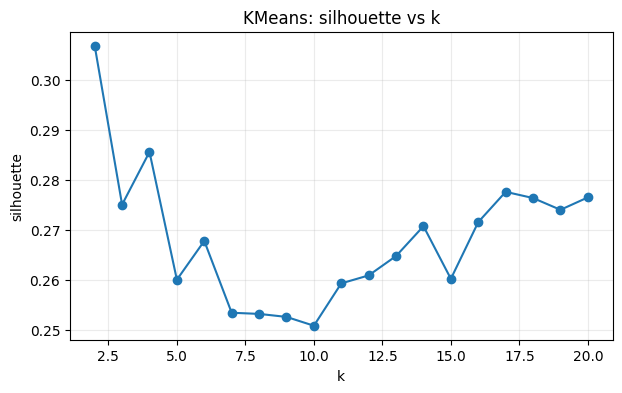

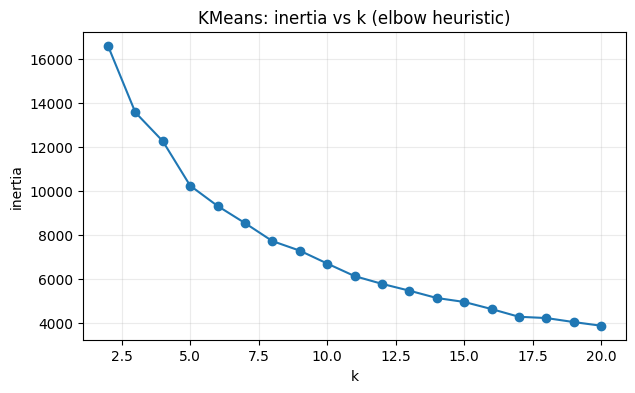

In [37]:
# Быстрый график silhouette по k (если silhouette считалась)
ks = [r["params"]["k"] for r in kmeans_results_2]
sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results_2]

plt.figure(figsize=(7, 4))
plt.plot(ks, sil, marker="o")
plt.title("KMeans: silhouette vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.savefig('artifacts/figures/KMeans_silhouette_vs_k_02.png')
plt.show()

# Инерция (elbow) – как эвристика
inertia = [r["inertia"] for r in kmeans_results_2]
plt.figure(figsize=(7, 4))
plt.plot(ks, inertia, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.savefig('artifacts/figures/KMeans_inertia_vs_k_(elbow_heuristic)_02.png')
plt.show()

In [38]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

best_kmeans_2, best_kmeans_s_2 = pick_best_by_silhouette(kmeans_results_2)
best_kmeans_2["params"], round(best_kmeans_s_2, 3)

({'k': 2}, 0.307)

Выберем “лучший” вариант по silhouette (это не единственный критерий, но для демо – удобно).

## DBSCAN (eps, min_samples) ВТОРОЙ ДАТАСЕТ

In [39]:

dbscan_results_2 = eval_dbscan_grid(X_2_processed_df, dbscan_eps, dbscan_min_samples)
len(dbscan_results_2)

28

In [40]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid = [r for r in dbscan_results_2 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid))

# Сортировка по silhouette
valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])


Valid DBSCAN configs: 10
{'eps': 0.7, 'min_samples': 15} sil= 0.349 noise= 0.051 clusters= 2
{'eps': 0.7, 'min_samples': 3} sil= 0.346 noise= 0.007 clusters= 2
{'eps': 0.7, 'min_samples': 10} sil= 0.305 noise= 0.036 clusters= 5
{'eps': 0.5, 'min_samples': 10} sil= 0.251 noise= 0.064 clusters= 2
{'eps': 0.4, 'min_samples': 5} sil= 0.135 noise= 0.062 clusters= 8
{'eps': 0.3, 'min_samples': 5} sil= 0.085 noise= 0.072 clusters= 5
{'eps': 0.5, 'min_samples': 5} sil= -0.058 noise= 0.045 clusters= 14
{'eps': 0.5, 'min_samples': 3} sil= -0.063 noise= 0.025 clusters= 32


In [41]:
best_dbscan_2 = valid_sorted[0] if valid_sorted else None
best_dbscan_2["params"] if best_dbscan_2 else "No valid config found"

{'eps': 0.7, 'min_samples': 15}

## Agglomerative (k, linkage) ВТОРОЙ ДАТАСЕТ

In [42]:
def eval_agglomerative_grid(X_feat, ks, linkages):
    results = []
    for linkage_name in linkages:
        for k in ks:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
                labels = model.fit_predict(X_feat)
            except Exception:
                continue

            metrics = safe_cluster_metrics(X_feat, labels)

            results.append({
                "algo": "agglomerative",
                "params": {"k": int(k), "linkage": linkage_name},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": len(np.unique(labels)),
                "noise_frac": 0.0,
            })
    return results

agg_results_2 = eval_agglomerative_grid(X_2_processed_df, agg_ks, agg_linkages)
len(agg_results_2), agg_results_2[0]["params"]


(57, {'k': 2, 'linkage': 'ward'})

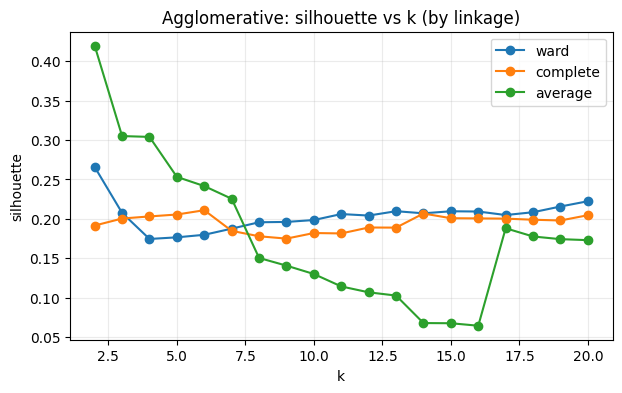

In [43]:
# Силуэт по k для разных linkage (на одном графике – удобно для сравнения)
plt.figure(figsize=(7, 4))

for linkage_name in agg_linkages:
    subset = [r for r in agg_results_2 if r["params"]["linkage"] == linkage_name]
    subset = sorted(subset, key=lambda r: r["params"]["k"])
    ks = [r["params"]["k"] for r in subset]
    sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in subset]
    plt.plot(ks, sil, marker="o", label=linkage_name)

plt.title("Agglomerative: silhouette vs k (by linkage)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig('artifacts/figures/Agglomerative_silhouette_vs_k_02.png')
plt.show()

In [44]:
best_agg_2, best_agg_s_2 = pick_best_by_silhouette(agg_results_2)
best_agg_2["params"], round(best_agg_s_2, 3)

({'k': 2, 'linkage': 'average'}, 0.42)

## Сводка кандидатов и выбор ВТОРОЙ ДАТАСЕТ

In [45]:
def print_result_card(name, result):
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3), " non-noise:", result.get("n_non_noise"))
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))

print_result_card("BEST KMEANS (by silhouette)", best_kmeans_2)
if best_dbscan_2 is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan_2)
print_result_card("BEST AGGLOMERATIVE (by silhouette)", best_agg_2)

BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.307
  davies_bouldin: 1.323
  calinski_harabasz: 3573.4
  inertia: 16588.5
BEST DBSCAN (by silhouette among valid)
algo: dbscan
params: {'eps': 0.7, 'min_samples': 15}
n_clusters: 2
noise_frac: 0.051  non-noise: 7596
metrics:
  silhouette: 0.349
  davies_bouldin: 0.82
  calinski_harabasz: 133.2
BEST AGGLOMERATIVE (by silhouette)
algo: agglomerative
params: {'k': 2, 'linkage': 'average'}
n_clusters: 2
metrics:
  silhouette: 0.42
  davies_bouldin: 0.879
  calinski_harabasz: 395.5


### Лучший алгоритм кластеризации: Agglomerative Clustering

**Обоснование выбора:**

- Баланс метрик: Agglomerative демонстрирует лучший silhouette (0.420) при хорошем Davies-Bouldin (0.879).

- Отсутствие шума: В отличие от DBSCAN, Agglomerative не помечает объекты как шум.

- Реалистичные значения Calinski-Harabasz: Значение 395.5 выглядит более правдоподобным по сравнению с аномально высоким 3573.4 у KMeans.

## Визуализация выбранных решений в 2D ВТОРОЙ ДАТАСЕТ


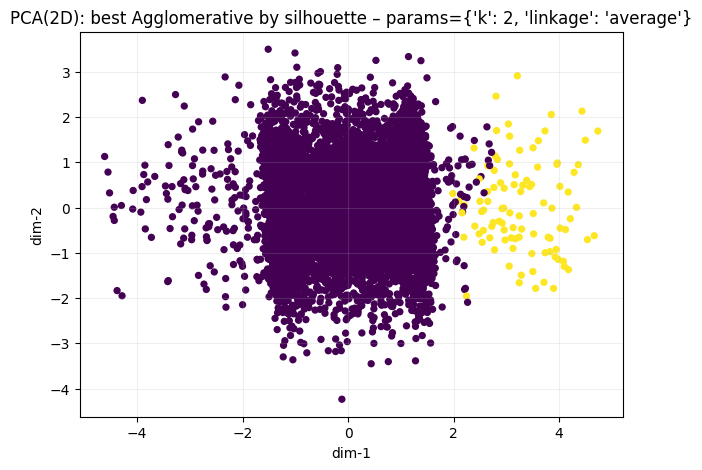

In [46]:
X_plot2d_2 = pca_2d_for_plot(X_2_processed_df, random_state=RANDOM_STATE)

# KMeans best
#plot_2d_embedding(
#    X_plot2d, best_kmeans["labels"],
#    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans['params']}"
#)
#plt.savefig('artifacts/figures/PCA(2D)_KMeans_01.png')
#plt.show()
# DBSCAN best (if exists)
#if best_dbscan is not None:
#    plot_2d_embedding(
#        X_plot2d, best_dbscan["labels"],
#        title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan['params']} (noise=-1)"
#    )
#    plt.savefig('artifacts/figures/PCA(2D)_DBSCAN_01.png')
#    plt.show()
# Agglomerative best
plot_2d_embedding(
    X_plot2d_2, best_agg_2["labels"],
    title=f"PCA(2D): best Agglomerative by silhouette – params={best_agg_2['params']}"
)
plt.savefig('artifacts/figures/PCA(2D)_Agglomerative_02.png')
plt.show()

## KMeans (подбор k) ТРЕТИЙ ДАТАСЕТ

In [47]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

kmeans_results_3 = eval_kmeans_grid(X_3_processed_df, kmeans_ks)
len(kmeans_results_3), kmeans_results_3[0]["params"], kmeans_results_3[-1]["params"]

(19, {'k': 2}, {'k': 20})

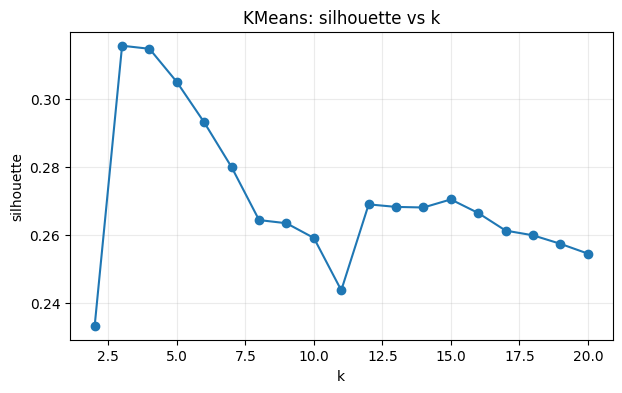

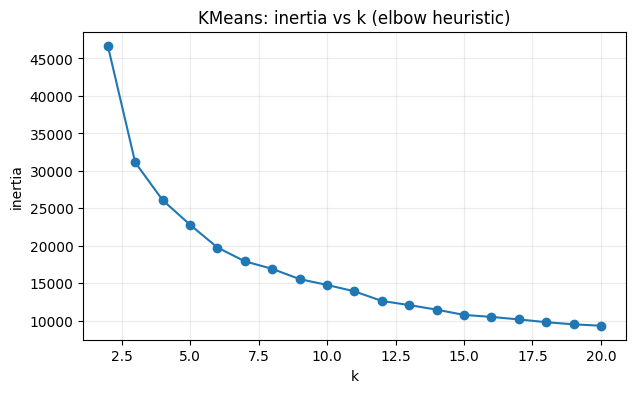

In [48]:
# Быстрый график silhouette по k (если silhouette считалась)
ks = [r["params"]["k"] for r in kmeans_results_3]
sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results_3]

plt.figure(figsize=(7, 4))
plt.plot(ks, sil, marker="o")
plt.title("KMeans: silhouette vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.savefig('artifacts/figures/KMeans_silhouette_vs_k_03.png')
plt.show()

# Инерция (elbow) – как эвристика
inertia = [r["inertia"] for r in kmeans_results_3]
plt.figure(figsize=(7, 4))
plt.plot(ks, inertia, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.savefig('artifacts/figures/KMeans_inertia_vs_k_(elbow_heuristic)_03.png')
plt.show()

In [49]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

best_kmeans_3, best_kmeans_s_3 = pick_best_by_silhouette(kmeans_results_3)
best_kmeans_3["params"], round(best_kmeans_s_3, 3)

({'k': 3}, 0.316)

## DBSCAN (eps, min_samples) ТРЕТИЙ ДАТАСЕТ

In [50]:
def eval_dbscan_grid_small(X_feat, eps_list, min_samples_list):
    """Адаптированная версия для малых данных"""
    results = []
    n = len(X_feat)
    
    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)
            
            noise_frac = float(np.mean(labels == -1))
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]
            
            # Перенумеровываем метки
            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)
            
            metrics = None
            n_clusters = 0
            
            # ИЗМЕНЕНО: более мягкие условия для малых данных
            if len(X_nn) >= 2 and len(np.unique(labels_nn)) >= 2:
                metrics = safe_cluster_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))
            elif len(X_nn) > 0:
                # Даже если только 1 кластер, считаем некоторые метрики
                n_clusters = len(np.unique(labels_nn))
                # Для 1 кластера silhouette не определен, но можно посчитать другие метрики
            
            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    
    return results

dbscan_results_3 = eval_dbscan_grid(X_3_processed_df, dbscan_eps, dbscan_min_samples)
len(dbscan_results_3)

28

In [51]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid = [r for r in dbscan_results_3 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid))

# Сортировка по silhouette
valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])


Valid DBSCAN configs: 13
{'eps': 0.3, 'min_samples': 15} sil= 0.269 noise= 0.299 clusters= 7
{'eps': 0.7, 'min_samples': 3} sil= 0.232 noise= 0.003 clusters= 3
{'eps': 0.4, 'min_samples': 15} sil= 0.224 noise= 0.103 clusters= 4
{'eps': 0.5, 'min_samples': 15} sil= 0.144 noise= 0.04 clusters= 2
{'eps': 0.5, 'min_samples': 10} sil= 0.142 noise= 0.032 clusters= 2
{'eps': 0.4, 'min_samples': 10} sil= 0.12 noise= 0.075 clusters= 4
{'eps': 0.3, 'min_samples': 10} sil= 0.038 noise= 0.216 clusters= 8
{'eps': 0.4, 'min_samples': 5} sil= -0.04 noise= 0.05 clusters= 6


In [52]:
best_dbscan_3 = valid_sorted[0] if valid_sorted else None
best_dbscan_3["params"] if best_dbscan_2 else "No valid config found"

{'eps': 0.3, 'min_samples': 15}

## Agglomerative (k, linkage) ТРЕТИЙ ДАТАСЕТ

In [53]:
def eval_agglomerative_grid(X_feat, ks, linkages):
    results = []
    for linkage_name in linkages:
        for k in ks:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
                labels = model.fit_predict(X_feat)
            except Exception:
                continue

            metrics = safe_cluster_metrics(X_feat, labels)

            results.append({
                "algo": "agglomerative",
                "params": {"k": int(k), "linkage": linkage_name},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": len(np.unique(labels)),
                "noise_frac": 0.0,
            })
    return results

agg_results_3 = eval_agglomerative_grid(X_3_processed_df, agg_ks, agg_linkages)
len(agg_results_3), agg_results_3[0]["params"]


(57, {'k': 2, 'linkage': 'ward'})

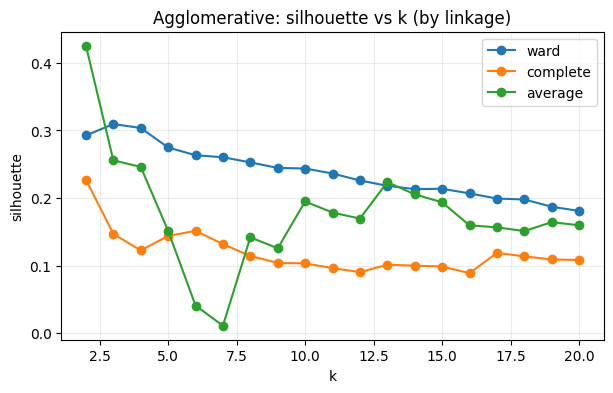

In [54]:
# Силуэт по k для разных linkage (на одном графике – удобно для сравнения)
plt.figure(figsize=(7, 4))

for linkage_name in agg_linkages:
    subset = [r for r in agg_results_3 if r["params"]["linkage"] == linkage_name]
    subset = sorted(subset, key=lambda r: r["params"]["k"])
    ks = [r["params"]["k"] for r in subset]
    sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in subset]
    plt.plot(ks, sil, marker="o", label=linkage_name)

plt.title("Agglomerative: silhouette vs k (by linkage)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig('artifacts/figures/Agglomerative_silhouette_vs_k_03.png')
plt.show()

In [55]:
best_agg_3, best_agg_s_3 = pick_best_by_silhouette(agg_results_3)
best_agg_3["params"], round(best_agg_s_3, 3)

({'k': 2, 'linkage': 'average'}, 0.425)

## Сводка кандидатов и выбор ТРЕТИЙ ДАТАСЕТ

In [56]:
def print_result_card(name, result):
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3), " non-noise:", result.get("n_non_noise"))
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))

print_result_card("BEST KMEANS (by silhouette)", best_kmeans_3)
if best_dbscan_3 is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan_3)
print_result_card("BEST AGGLOMERATIVE (by silhouette)", best_agg_3)

BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 3}
n_clusters: 3
metrics:
  silhouette: 0.316
  davies_bouldin: 1.158
  calinski_harabasz: 6957.2
  inertia: 31123.5
BEST DBSCAN (by silhouette among valid)
algo: dbscan
params: {'eps': 0.3, 'min_samples': 15}
n_clusters: 7
noise_frac: 0.299  non-noise: 10510
metrics:
  silhouette: 0.269
  davies_bouldin: 1.01
  calinski_harabasz: 3927.6
BEST AGGLOMERATIVE (by silhouette)
algo: agglomerative
params: {'k': 2, 'linkage': 'average'}
n_clusters: 2
metrics:
  silhouette: 0.425
  davies_bouldin: 0.814
  calinski_harabasz: 8.9


### Анализ и выбор алгоритма кластеризации

**Наименее проблематичный алгоритм:**
    - DBSCAN отбрасывает 30% данных — неприемлемо
    - Agglomerative имеет нереалистично низкий Calinski-Harabasz (8.9)

**У KMeans:**
    - Все три метрики имеют правдоподобные значения
    - Silhouette (0.316) и Davies-Bouldin (1.158) согласованы
    - Высокий Calinski-Harabasz (6957.2) может быть оправдан структурой данных
    - 3 кластера более информативно, чем 2 у Agglomerative
    - KMeans использует все данные (0% шума)


## Визуализация выбранных решений в 2D ТРЕТИЙ ДАТАСЕТ

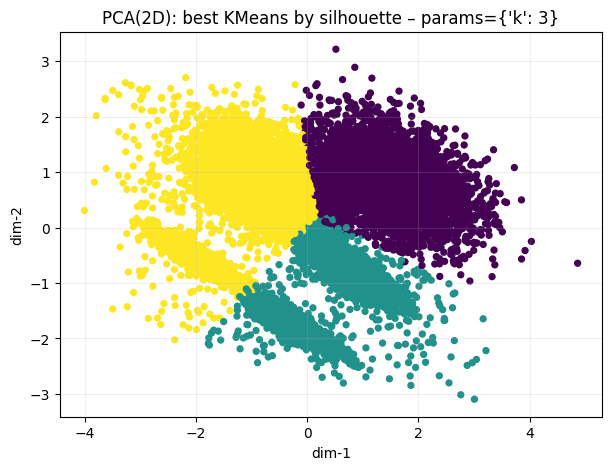

In [57]:
X_plot2d_3 = pca_2d_for_plot(X_3_processed_df, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X_plot2d_3, best_kmeans_3["labels"],
    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans_3['params']}"
)
plt.savefig('artifacts/figures/PCA(2D)_KMeans_03.png')
plt.show()
# DBSCAN best (if exists)
#if best_dbscan is not None:
#    plot_2d_embedding(
#        X_plot2d, best_dbscan["labels"],
#        title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan['params']} (noise=-1)"
#    )
#    plt.savefig('artifacts/figures/PCA(2D)_DBSCAN_01.png')
#    plt.show()
# Agglomerative best
#plot_2d_embedding(
#    X_plot2d_3, best_agg_3["labels"],
#    title=f"PCA(2D): best Agglomerative by silhouette – params={best_agg_3['params']}"
#)
#plt.savefig('artifacts/figures/PCA(2D)_Agglomerative_03.png')
#plt.show()

In [58]:
def save_clustering_results(datasets_config):    
    metrics_summary = {}
    best_configs = {}
    
    for ds_name, ds_name_label, kmeans_best, dbscan_best, agg_best, sample_ids, X_scaled, best_overall in datasets_config:
        print(f"\n ДАТАСЕТ: {ds_name}")
        print(f"   Объектов: {len(sample_ids)}, Признаков: {X_scaled.shape[1]}")
        
        metrics_summary[ds_name] = {}
        best_configs[ds_name] = {}
        
        # Добавляем информацию о датасете
        metrics_summary[ds_name]['dataset_info'] = {
            'n_samples': len(sample_ids),
            'n_features': X_scaled.shape[1]
        }
        
        # ===== KMeans метрики =====
        print(f"   KMeans: silhouette={kmeans_best['metrics']['silhouette']:.3f}")
        
        metrics_summary[ds_name]['kmeans'] = {
            'silhouette': float(kmeans_best['metrics']['silhouette']),
            'davies_bouldin': float(kmeans_best['metrics']['davies_bouldin']),
            'calinski_harabasz': float(kmeans_best['metrics']['calinski_harabasz']),
            'noise_fraction': 0.0,  # KMeans не имеет шума
            'n_clusters': int(kmeans_best['n_clusters']),
            'algorithm': 'KMeans',
            'additional_metrics': {
                'inertia': float(kmeans_best.get('inertia', 0))
            }
        }
        
        best_configs[ds_name]['kmeans'] = {
            'params': kmeans_best['params'],
            'selection_criterion': 'max_silhouette_score',
            'metrics': {
                'silhouette': float(kmeans_best['metrics']['silhouette']),
                'davies_bouldin': float(kmeans_best['metrics']['davies_bouldin']),
                'calinski_harabasz': float(kmeans_best['metrics']['calinski_harabasz'])
            }
        }
        
        # ===== DBSCAN метрики =====
        if dbscan_best and dbscan_best['metrics'] is not None:
            noise_frac = float(dbscan_best.get('noise_frac', 0.0))
            print(f"   DBSCAN: silhouette={dbscan_best['metrics']['silhouette']:.3f}, noise={noise_frac:.3f}")
            
            metrics_summary[ds_name]['dbscan'] = {
                'silhouette': float(dbscan_best['metrics']['silhouette']),
                'davies_bouldin': float(dbscan_best['metrics']['davies_bouldin']),
                'calinski_harabasz': float(dbscan_best['metrics']['calinski_harabasz']),
                'noise_fraction': noise_frac,
                'n_clusters': int(dbscan_best.get('n_clusters', 0)),
                'algorithm': 'DBSCAN',
                'additional_metrics': {
                    'n_non_noise': int(dbscan_best.get('n_non_noise', 0)),
                    'eps': float(dbscan_best['params'].get('eps', 0)),
                    'min_samples': int(dbscan_best['params'].get('min_samples', 0))
                }
            }
            
            best_configs[ds_name]['dbscan'] = {
                'params': dbscan_best['params'],
                'selection_criterion': 'max_silhouette_score',
                'metrics': {
                    'silhouette': float(dbscan_best['metrics']['silhouette']),
                    'davies_bouldin': float(dbscan_best['metrics']['davies_bouldin']),
                    'calinski_harabasz': float(dbscan_best['metrics']['calinski_harabasz']),
                    'noise_fraction': noise_frac
                }
            }
        else:
            print(f"   DBSCAN: нет валидных конфигураций")

        # ===== Agglomerative Clustering метрики =====
        if agg_best and agg_best['metrics'] is not None:
            print(f"   Agglomerative Clustering: silhouette={agg_best['metrics']['silhouette']:.3f}")
            
            metrics_summary[ds_name]['agglomerative'] = {
                'silhouette': float(agg_best['metrics']['silhouette']),
                'davies_bouldin': float(agg_best['metrics']['davies_bouldin']),
                'calinski_harabasz': float(agg_best['metrics']['calinski_harabasz']),
                'noise_fraction': 0.0,  # Agglomerative не имеет шума
                'n_clusters': int(agg_best['n_clusters']),
                'algorithm': 'AgglomerativeClustering',
                'additional_metrics': {
                    'linkage': agg_best['params'].get('linkage', 'unknown'),
                    'distance_threshold': agg_best['params'].get('distance_threshold', None)
                }
            }
            
            best_configs[ds_name]['agglomerative'] = {
                'params': agg_best['params'],
                'selection_criterion': 'max_silhouette_score',
                'metrics': {
                    'silhouette': float(agg_best['metrics']['silhouette']),
                    'davies_bouldin': float(agg_best['metrics']['davies_bouldin']),
                    'calinski_harabasz': float(agg_best['metrics']['calinski_harabasz'])
                }
            }
        else:
            print(f"   Agglomerative Clustering: нет результатов")
        
        # ===== Определяем лучший алгоритм (по выбору пользователя или по метрике) =====
        best_algorithm = None
        best_labels = None
        best_params = None
        
        # Словарь для доступа к результатам алгоритмов
        algorithm_results = {
            'kmeans': (kmeans_best['metrics']['silhouette'], kmeans_best['labels'], kmeans_best['params']),
            'dbscan': (dbscan_best['metrics']['silhouette'] if dbscan_best and dbscan_best['metrics'] is not None else None,
                      dbscan_best['labels'] if dbscan_best else None,
                      dbscan_best['params'] if dbscan_best else None),
            'agglomerative': (agg_best['metrics']['silhouette'] if agg_best and agg_best['metrics'] is not None else None,
                             agg_best['labels'] if agg_best else None,
                             agg_best['params'] if agg_best else None)
        }
        
        # Проверяем выбор пользователя
        if best_overall:
            if best_overall in algorithm_results:
                silhouette, labels, params = algorithm_results[best_overall]
                if labels is not None:  # Проверяем, что алгоритм был успешно обучен
                    best_algorithm = best_overall
                    best_labels = labels
                    best_params = params
                else:
                    best_overall = None  # Сбрасываем выбор
            else:
                best_overall = None    
        
        # ===== Сохраняем информацию о лучшем алгоритме =====
        best_algo_metrics = metrics_summary[ds_name].get(best_algorithm, {})
        
        best_configs[ds_name]['best_overall'] = {
            'algorithm': best_algorithm,
            'params': best_params,
            'comparison_with_others': {
                'kmeans': {
                    'silhouette': float(kmeans_best['metrics']['silhouette']),
                    'n_clusters': int(kmeans_best['n_clusters'])
                },
                'dbscan': {
                    'silhouette': float(dbscan_best['metrics']['silhouette']) if dbscan_best and dbscan_best['metrics'] is not None else None,
                    'n_clusters': int(dbscan_best['n_clusters']) if dbscan_best else None,
                    'noise_fraction': float(dbscan_best.get('noise_frac', 0)) if dbscan_best else None
                } if dbscan_best else None,
                'agglomerative': {
                    'silhouette': float(agg_best['metrics']['silhouette']) if agg_best and agg_best['metrics'] is not None else None,
                    'n_clusters': int(agg_best['n_clusters']) if agg_best else None,
                    'linkage': agg_best['params'].get('linkage', 'unknown') if agg_best else None
                } if agg_best else None
            },
            'metrics': {
                'silhouette': float(best_algo_metrics.get('silhouette', 0)),
                'davies_bouldin': float(best_algo_metrics.get('davies_bouldin', 0)),
                'calinski_harabasz': float(best_algo_metrics.get('calinski_harabasz', 0)),
                'noise_fraction': float(best_algo_metrics.get('noise_fraction', 0)),
                'n_clusters': int(best_algo_metrics.get('n_clusters', 0))
            } if best_algo_metrics else {}
        }
        
        # ===== Сохраняем labels лучшего алгоритма =====
        labels_df = pd.DataFrame({
            'sample_id': sample_ids,
            'cluster_label': best_labels
        })
        
        # Сортируем по sample_id для удобства
        labels_df = labels_df.sort_values('sample_id').reset_index(drop=True)
        
        # Сохраняем CSV
        csv_filename = f'artifacts/labels/labels_hw07_{ds_name_label}.csv'
        labels_df.to_csv(csv_filename, index=False)
        
        print(f"CSV сохранен: {csv_filename}")
    
    # 1. metrics_summary.json
    metrics_path = 'artifacts/metrics_summary.json'
    with open(metrics_path, 'w', encoding='utf-8') as f:
        json.dump(metrics_summary, f, indent=2, ensure_ascii=False, default=str)
    print(f" metrics_summary.json: {metrics_path}")
    
    # 2. best_configs.json
    configs_path = 'artifacts/best_configs.json'
    with open(configs_path, 'w', encoding='utf-8') as f:
        json.dump(best_configs, f, indent=2, ensure_ascii=False, default=str)
    print(f" best_configs.json: {configs_path}")
    
    return metrics_summary, best_configs
datasets_config = [
        # (имя_датасета, kmeans_best, dbscan_best, agg_best, sample_ids, X_scaled)
        ('S07-hw-dataset-01', 'ds1', best_kmeans, best_dbscan, best_agg, sample_id, X_processed_df, "dbscan"),
        ('S07-hw-dataset-02', 'ds2', best_kmeans_2, best_dbscan_2, best_agg_2, sample_id2, X_2_processed_df, "agglomerative"),
        ('S07-hw-dataset-03', 'ds3', best_kmeans_3, best_dbscan_3, best_agg_3, sample_id3, X_3_processed_df, "kmeans")
    ]
metrics, configs = save_clustering_results(datasets_config)


 ДАТАСЕТ: S07-hw-dataset-01
   Объектов: 12000, Признаков: 8
   KMeans: silhouette=0.522
   DBSCAN: silhouette=0.522, noise=0.000
   Agglomerative Clustering: silhouette=0.522
CSV сохранен: artifacts/labels/labels_hw07_ds1.csv

 ДАТАСЕТ: S07-hw-dataset-02
   Объектов: 8000, Признаков: 3
   KMeans: silhouette=0.307
   DBSCAN: silhouette=0.349, noise=0.051
   Agglomerative Clustering: silhouette=0.420
CSV сохранен: artifacts/labels/labels_hw07_ds2.csv

 ДАТАСЕТ: S07-hw-dataset-03
   Объектов: 15000, Признаков: 4
   KMeans: silhouette=0.316
   DBSCAN: silhouette=0.269, noise=0.299
   Agglomerative Clustering: silhouette=0.425
CSV сохранен: artifacts/labels/labels_hw07_ds3.csv
 metrics_summary.json: artifacts/metrics_summary.json
 best_configs.json: artifacts/best_configs.json
